In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
# Read Dataset
df=pd.read_json('val_data.json',lines=True)
df.head()

,image_url,image_path,brand,product_title,class_label,color
0,https://m.media-amazon.com/images/I/81LOPbFPiQ...,images/val/0.jpeg,Generic,Women's Khadi Cotton Saree With Blouse Piece (...,saree,NaN
1,https://m.media-amazon.com/images/I/81Q8Oktw4s...,images/val/1.jpeg,Yashvi Designer,Women's Net Saree With Unstitched Blouse Piece,saree,NaN
2,https://m.media-amazon.com/images/I/613S1YGCmo...,images/val/2.jpeg,Aarrah,Georgette Strip Print Saree[S_SHIKHA30021SR02_...,saree,NaN
3,https://m.media-amazon.com/images/I/819budhQl1...,images/val/3.jpeg,MIMOSA,Women's Patola Style Art Silk Saree (Green),saree,NaN
4,https://m.media-amazon.com/images/I/61cAZ94ZQV...,images/val/4.jpeg,Generic,Women's Pure Hand Block Patola Printed Cotton ...,saree,NaN


In [3]:
df.shape

(7500, 6)

In [4]:
#Class Distribution
df['class_label'].value_counts()

class_label
saree                   500
blouse                  500
dhoti_pants             500
dupattas                500
gowns                   500
kurta_men               500
leggings_and_salwars    500
lehenga                 500
mojaris_men             500
mojaris_women           500
nehru_jackets           500
palazzos                500
petticoats              500
sherwanis               500
women_kurta             500
Name: count, dtype: int64

In [5]:
#keeping required cloumn only
df = df[['image_path', 'class_label']]
df.head()


,image_path,class_label
0,images/val/0.jpeg,saree
1,images/val/1.jpeg,saree
2,images/val/2.jpeg,saree
3,images/val/3.jpeg,saree
4,images/val/4.jpeg,saree


In [6]:
#checking for any null or nan values
print('Null Values:\n',df.isnull().sum())
print('NaN Values:\n',df.isna().sum())

Null Values:
 image_path     0
class_label    0
dtype: int64
NaN Values:
 image_path     0
class_label    0
dtype: int64


In [7]:
#converting the categorical value into numberic label
le=LabelEncoder()
df['class_label']=le.fit_transform(df['class_label'])
dict(zip(le.classes_, le.transform(le.classes_)))

{'blouse': np.int64(0),
 'dhoti_pants': np.int64(1),
 'dupattas': np.int64(2),
 'gowns': np.int64(3),
 'kurta_men': np.int64(4),
 'leggings_and_salwars': np.int64(5),
 'lehenga': np.int64(6),
 'mojaris_men': np.int64(7),
 'mojaris_women': np.int64(8),
 'nehru_jackets': np.int64(9),
 'palazzos': np.int64(10),
 'petticoats': np.int64(11),
 'saree': np.int64(12),
 'sherwanis': np.int64(13),
 'women_kurta': np.int64(14)}

In [8]:
#making a train test split ensuring equal proportion of subclass in both the dataset
train_df, test_df = train_test_split(
    df, test_size=0.3, stratify=df["class_label"], random_state=42
)


In [9]:
print('Train Dataset Shape:',train_df.shape)
print('Test Dataset Shape:',test_df.shape)


Train Dataset Shape: (5250, 2)
Test Dataset Shape: (2250, 2)


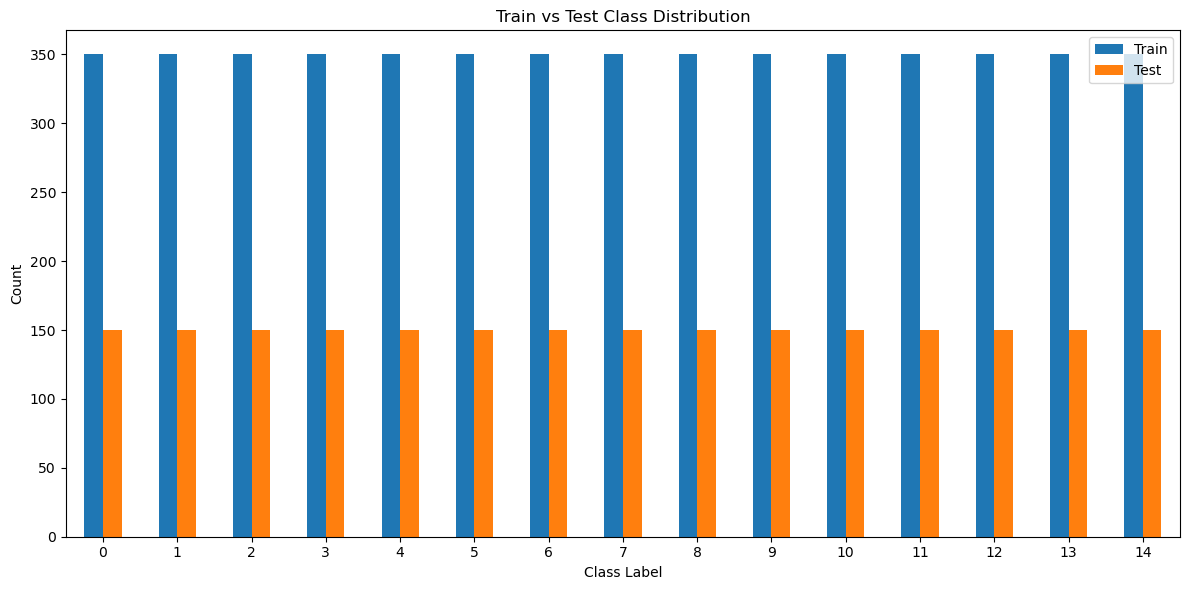

In [10]:
train_counts = train_df['class_label'].value_counts().sort_index()
test_counts = test_df['class_label'].value_counts().sort_index()

df_plot = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

df_plot.plot(kind='bar', figsize=(12,6))

plt.title('Train vs Test Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
#creating class for data loader that will take the image from the path and make it ML ready
class ImageDataLoader:
    def __init__(self, df, img_size=(128, 256), batch_size=32, shuffle=True):
        self.df = df
        self.img_size = img_size
        self.batch_size = batch_size
        self.shuffle = shuffle

    #below function will store the image_path and label pair 
    def _df_to_dataset(self):
        paths = self.df["image_path"].values
        labels = self.df["class_label"].values
        return tf.data.Dataset.from_tensor_slices((paths, labels))

    #this function will read image and resize it and return image label pair
    def _load_image(self, path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        
        img = tf.image.resize(img, self.img_size)
        img = img / 255.0
        
        return img, label

    #below function will run only if augment is set True this will twick the image diffrent ways 
    def _augment(self, img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        return img, label

    #this function will return the dataset in batches for train and test
    def get_dataset(self, augment=False):
        ds = self._df_to_dataset()
        
        ds = ds.map(self._load_image, num_parallel_calls=tf.data.AUTOTUNE)
        
        if self.shuffle:
            ds = ds.shuffle(buffer_size=1000)
        
        if augment:
            ds = ds.map(self._augment, num_parallel_calls=tf.data.AUTOTUNE)
        
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        
        return ds

In [12]:
train_dataset = ImageDataLoader(train_df)
test_dataset = ImageDataLoader(test_df, shuffle=False)

train_ds = train_dataset.get_dataset(augment=True)
test_ds = test_dataset.get_dataset()

In [13]:
print("Training Dataset Size:")
print("Samples:", len(train_df))
print("Batch size:", train_dataset.batch_size)
print("Batches:", len(train_ds))

print("\nTraining Dataset Size:")
print("Samples:", len(test_df))
print("Batch size:", test_dataset.batch_size)
print("Batches:", len(test_ds))

Training Dataset Size:
Samples: 5250
Batch size: 32
Batches: 165

Training Dataset Size:
Samples: 2250
Batch size: 32
Batches: 71


# Model Training: Resnet

In [14]:
num_classes = len(train_df["class_label"].unique())

base_model = tf.keras.applications.ResNet50(
    input_shape=(128, 256, 3),
    include_top=False,
    weights='imagenet'
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [15]:
base_model.trainable=False

In [16]:
model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [17]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history_resnet = model_resnet.fit(
    train_ds,
    epochs=15
)

Epoch 1/15


165/165 ━━━━━━━━━━━━━━━━━━━━ 97s 583ms/step - accuracy: 0.5880 - loss: 1.2723
Epoch 2/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 97s 586ms/step - accuracy: 0.5985 - loss: 1.2210
Epoch 3/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 139s 841ms/step - accuracy: 0.6286 - loss: 1.1426
Epoch 4/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 153s 923ms/step - accuracy: 0.6291 - loss: 1.1260
Epoch 5/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 157s 936ms/step - accuracy: 0.6526 - loss: 1.0632
Epoch 6/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 157s 948ms/step - accuracy: 0.6550 - loss: 1.0346
Epoch 7/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 129s 775ms/step - accuracy: 0.6693 - loss: 0.9984
Epoch 8/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 128s 769ms/step - accuracy: 0.6754 - loss: 0.9731
Epoch 9/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 120s 719ms/step - accuracy: 0.6842 - loss: 0.9679
Epoch 10/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 118s 717ms/step - accuracy: 0.6939 - loss: 0.9284
Epoch 11/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 168s 872ms/step - accuracy: 0.6912 - loss: 0.9159
Epoch 12/15
165/165 ━

In [21]:
# Unfreeze last 30 layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet_fine = model_resnet.fit(
    train_ds,
    epochs=10
)

Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 128s 713ms/step - accuracy: 0.3419 - loss: 6.1016
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 115s 694ms/step - accuracy: 0.4781 - loss: 3.5973
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 116s 702ms/step - accuracy: 0.5215 - loss: 2.8647
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 122s 737ms/step - accuracy: 0.5554 - loss: 2.4721
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 117s 706ms/step - accuracy: 0.5815 - loss: 2.1198
Epoch 6/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 115s 696ms/step - accuracy: 0.6065 - loss: 1.9431
Epoch 7/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 115s 698ms/step - accuracy: 0.6229 - loss: 1.7510
Epoch 8/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 119s 722ms/step - accuracy: 0.6499 - loss: 1.5270
Epoch 9/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 115s 698ms/step - accuracy: 0.6539 - loss: 1.4610
Epoch 10/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 115s 696ms/step - accuracy: 0.6589 - loss: 1.4201


In [22]:
#Evaluating model performance on test dataset
loss, accuracy = model_resnet.evaluate(test_ds)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 36s 477ms/step - accuracy: 0.6156 - loss: 2.0213
Test Loss: 2.0212628841400146
Test Accuracy: 0.6155555844306946


In [23]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_resnet.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [24]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80       150
           1       0.58      0.44      0.50       150
           2       0.40      0.35      0.38       150
           3       0.57      0.47      0.51       150
           4       0.50      0.72      0.59       150
           5       0.52      0.50      0.51       150
           6       0.80      0.65      0.72       150
           7       0.76      0.69      0.72       150
           8       0.65      0.76      0.70       150
           9       0.75      0.65      0.69       150
          10       0.65      0.71      0.68       150
          11       0.62      0.74      0.67       150
          12       0.59      0.65      0.62       150
          13       0.70      0.59      0.64       150
          14       0.44      0.54      0.49       150

    accuracy                           0.62      2250
   macro avg       0.62      0.62      0.62      2250
weighted avg       0.62   

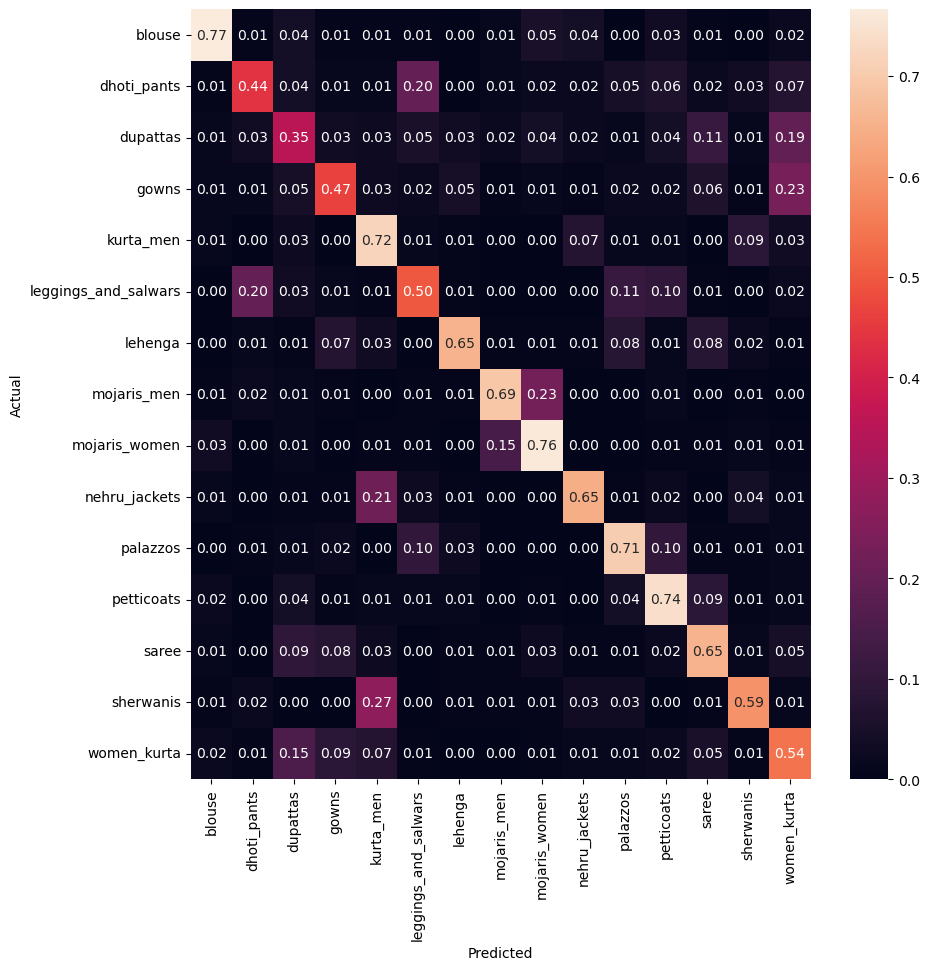

In [25]:
cm = confusion_matrix(y_true, y_pred)
# Normalise
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)